# AdroitHandDoor — SAC

Desarrollo incremental de los capítulos 1–5. El Capítulo 6 (informe técnico) queda fuera de este DWP y pendiente para la entrega académica. Las salidas locales no prueban ejecución en Colab.

## Capítulo 1 — Librerías, bootstrap y variables transversales

Se preserva el entorno `AdroitHandDoor-v1`, incluida la recompensa histórica. Las versiones siguientes son una combinación validada localmente; su validación definitiva en Colab está pendiente.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
DEPENDENCIES = {
    "gymnasium-robotics": "1.3.0", "gymnasium": "1.0.0",
    "mujoco": "3.1.6", "stable-baselines3": "2.4.1",
    "torch": "2.5.1", "numpy": "1.26.4",
}
if IN_COLAB:
    os.environ["MUJOCO_GL"] = "egl"
    subprocess.run([sys.executable, "-m", "pip", "install",
                    *[f"{k}=={v}" for k, v in DEPENDENCIES.items()],
                    "imageio", "imageio-ffmpeg", "pillow"], check=True)


In [2]:
import hashlib
import inspect
import json
import platform
import random
import time
from datetime import datetime, timezone
from importlib.metadata import version

import gymnasium as gym
import gymnasium_robotics
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import SAC
from IPython.display import display

CONFIG = {
    "env_id": "AdroitHandDoor-v1", "algorithm": "SAC", "policy": "MlpPolicy",
    "profile": "smoke", "timesteps": {"smoke": 5_000, "full": 500_000},
    "train_seed": 42, "baseline_seeds": list(range(101, 111)), "tuning_seeds": list(range(201, 206)),
    "final_seeds": list(range(1001, 1011)), "video_seed": 301,
    "eval_freq": 25_000, "checkpoint_freq": 50_000,
    "smoke_eval_freq": 2_500, "smoke_checkpoint_freq": 2_500,
    "target_success_rate": 0.80,
    "sac": {"learning_rate": 3e-4, "gamma": 0.99, "tau": 0.005,
            "batch_size": 256, "buffer_size": 500_000, "train_freq": 1,
            "gradient_steps": 1, "ent_coef": "auto", "target_entropy": "auto",
            "policy_kwargs": {"net_arch": [256, 256]}},
    "learning_starts": {"smoke": 500, "full": 10_000},
    "video_fps": 30, "video_episodes": 1, "device": "cuda" if IN_COLAB and torch.cuda.is_available() else "cpu", "torch_threads": 1,
    "smoke_eval_seeds": [401, 402],
    "expected_horizon": 200, "expected_frame_skip": 5,
    "obs_dim": 39, "action_dim": 28, "success_threshold": 1.35,
    "render_train": None, "render_video": "rgb_array",
}
# Una raíz: abrir desde la raíz del repo o desde la carpeta del notebook.
MODEL_FOLDER = "1-AdroitHandDoor"
PROJECT_ROOT = (Path("/content") / MODEL_FOLDER if IN_COLAB else
                Path.cwd() if Path.cwd().name == MODEL_FOLDER else Path.cwd() / MODEL_FOLDER)
MODEL_DIR = PROJECT_ROOT / "models"
VIDEO_DIR = PROJECT_ROOT / "videos"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RUNS_DIR = PROJECT_ROOT / "runs"
SMOKE_DIR = PROJECT_ROOT.parent / "tmp" / "adroit_smoke"
FINAL_MODEL_PATH = MODEL_DIR / "adroit_hand_door_sac.zip"
FINAL_METADATA_PATH = FINAL_MODEL_PATH.with_suffix(".metadata.json")
for folder in (MODEL_DIR, VIDEO_DIR, RESULTS_DIR, FIGURES_DIR, RUNS_DIR):
    folder.mkdir(parents=True, exist_ok=True)
random.seed(CONFIG["train_seed"])
np.random.seed(CONFIG["train_seed"])
torch.manual_seed(CONFIG["train_seed"])
torch.set_num_threads(CONFIG["torch_threads"])
gym.register_envs(gymnasium_robotics)
VERSIONS = {name: version(name) for name in DEPENDENCIES}
assert VERSIONS == DEPENDENCIES, (VERSIONS, DEPENDENCIES)
HARDWARE = {"platform": platform.platform(), "machine": platform.machine(),
            "python": platform.python_version(), "cuda_available": torch.cuda.is_available(),
            "mps_available": torch.backends.mps.is_available(), "device": CONFIG["device"]}
print(json.dumps({"versions": VERSIONS, "hardware": HARDWARE}, indent=2))


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


{
  "versions": {
    "gymnasium-robotics": "1.3.0",
    "gymnasium": "1.0.0",
    "mujoco": "3.1.6",
    "stable-baselines3": "2.4.1",
    "torch": "2.5.1",
    "numpy": "1.26.4"
  },
  "hardware": {
    "platform": "macOS-26.6.2-arm64-arm-64bit",
    "machine": "arm64",
    "python": "3.12.13",
    "cuda_available": false,
    "mps_available": true,
    "device": "cpu"
  }
}


In [3]:
def make_env(render_mode=None, seed=None):
    """Create the unmodified task environment and seed its spaces.

    Args:
        render_mode: Gymnasium rendering mode, or None for training.
        seed: Optional seed for reset and action/observation spaces.

    Returns:
        A Gymnasium environment owned by the caller, which must close it.
    """
    env = gym.make(CONFIG["env_id"], render_mode=render_mode)
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
        env.observation_space.seed(seed)
    return env


def evaluate_policy(model, seeds):
    """Evaluate full episodes without learning, using any-step success.

    Args:
        model: SB3 model for deterministic inference, or None for random actions.
        seeds: Environment seeds, one per episode.

    Returns:
        DataFrame of returns, lengths, success and physical diagnostics.
    """
    records = []
    env = make_env()
    try:
        for seed in seeds:
            obs, info = env.reset(seed=int(seed))
            env.action_space.seed(int(seed))
            total, length, success = 0.0, 0, False
            max_angle, min_distance = -float("inf"), float("inf")
            terminated = truncated = False
            while not (terminated or truncated):
                action = env.action_space.sample() if model is None else model.predict(obs, deterministic=True)[0]
                obs, reward, terminated, truncated, info = env.step(action)
                assert np.isfinite(reward) and np.isfinite(obs).all()
                total += float(reward)
                length += 1
                success = success or bool(info["success"])
                base = env.unwrapped
                max_angle = max(max_angle, float(base.data.qpos[base.door_hinge_addrs]))
                min_distance = min(min_distance, float(np.linalg.norm(
                    base.data.site_xpos[base.grasp_site_id] - base.data.site_xpos[base.handle_site_id])))
            records.append({"seed": int(seed), "episode_return": total, "episode_length": length,
                            "success": success, "success_any": success,
                            "max_door_hinge": max_angle, "min_palm_handle_distance": min_distance})
    finally:
        env.close()
    return pd.DataFrame(records)


{
  "captured_at": "2026-09-11T23:13:54.930961+00:00",
  "execution_target": "local",
  "environment_id": "AdroitHandDoor-v1",
  "env_spec": "EnvSpec(id='AdroitHandDoor-v1', entry_point='gymnasium_robotics.envs.adroit_hand.adroit_door:AdroitHandDoorEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={'reward_type': 'dense', 'render_mode': 'rgb_array'}, namespace=None, name='AdroitHandDoor', version=1, additional_wrappers=(), vector_entry_point=None)",
  "versions": {
    "gymnasium-robotics": "1.3.0",
    "gymnasium": "1.0.0",
    "mujoco": "3.1.6",
    "stable-baselines3": "2.4.1",
    "torch": "2.5.1",
    "numpy": "1.26.4"
  },
  "hardware": {
    "platform": "macOS-26.6.2-arm64-arm-64bit",
    "machine": "arm64",
    "python": "3.12.13",
    "cuda_available": false,
    "mps_available": true,
    "device": "cpu"
  },
  "max_episode_steps": 200,
  "frame_skip": 5,
  "action_space": "Box(-1.0, 1.0, (28,), f

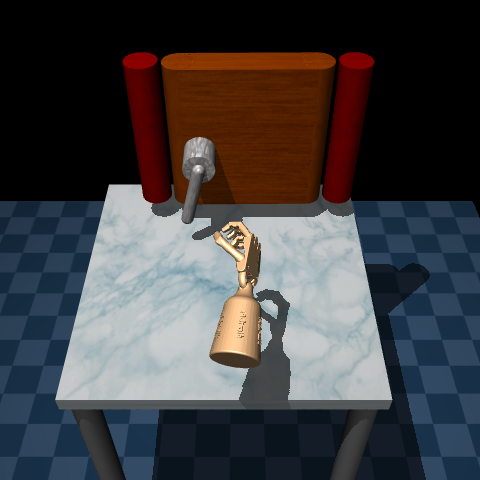

In [4]:
probe_env = make_env(render_mode=CONFIG["render_video"])
try:
    obs, info = probe_env.reset(seed=CONFIG["train_seed"])
    probe_env.action_space.seed(CONFIG["train_seed"])
    base = probe_env.unwrapped
    assert obs.shape == (CONFIG["obs_dim"],)
    assert probe_env.action_space.shape == (CONFIG["action_dim"],)
    assert np.all(probe_env.action_space.low == -1) and np.all(probe_env.action_space.high == 1)
    assert probe_env.spec.max_episode_steps == CONFIG["expected_horizon"]
    assert base.frame_skip == CONFIG["expected_frame_skip"]
    reward_samples = []
    for step in range(1, CONFIG["expected_horizon"] + 1):
        obs, reward, terminated, truncated, info = probe_env.step(probe_env.action_space.sample())
        assert np.isfinite(reward) and np.isfinite(obs).all()
        theta = float(base.data.qpos[base.door_hinge_addrs])
        distance = float(np.linalg.norm(base.data.site_xpos[base.grasp_site_id] -
                                        base.data.site_xpos[base.handle_site_id]))
        expected = 0.1 * distance - 0.1 * (theta - 1.57)**2 - 1e-5 * np.sum(base.data.qvel**2)
        expected += 2 * (theta > 0.2) + 8 * (theta > 1.0) + 10 * (theta > 1.35)
        assert np.isclose(reward, expected, rtol=1e-10, atol=1e-10)
        assert bool(info["success"]) == (theta >= CONFIG["success_threshold"])
        assert not terminated
        assert truncated == (step == CONFIG["expected_horizon"])
        if step <= 3:
            reward_samples.append({"step": step, "reward": float(reward),
                                   "reconstructed_reward": float(expected)})
    frame = probe_env.render()
    assert frame.ndim == 3 and frame.shape[-1] == 3
    actuators = []
    for i in range(base.model.nu):
        joint = int(base.model.actuator_trnid[i, 0])
        actuators.append({"name": base.model.actuator(i).name,
                          "ctrlrange": base.model.actuator_ctrlrange[i].tolist(),
                          "joint": base.model.joint(joint).name,
                          "joint_range": base.model.jnt_range[joint].tolist()})
    source = inspect.getsource(type(base).step)
    contract = {"captured_at": datetime.now(timezone.utc).isoformat(),
                "execution_target": "colab" if IN_COLAB else "local",
                "environment_id": probe_env.spec.id, "env_spec": str(probe_env.spec),
                "versions": VERSIONS, "hardware": HARDWARE,
                "max_episode_steps": probe_env.spec.max_episode_steps,
                "frame_skip": base.frame_skip, "action_space": str(probe_env.action_space),
                "observation_space": str(probe_env.observation_space), "actuators": actuators,
                "reward_distance_coefficient": 0.1, "reward_probe": reward_samples,
                "reward_source_sha256": hashlib.sha256(source.encode()).hexdigest(),
                "validated_steps": step, "truncated_at": step, "render_shape": list(frame.shape),
                "range_note": "Joint limits and actuator control ranges are distinct; no physics modifications."}
finally:
    probe_env.close()
contract["closed"] = True
(RESULTS_DIR / "runtime_contract.json").write_text(json.dumps(contract, indent=2) + "\n")
print(json.dumps(contract, indent=2))
from PIL import Image
display(Image.fromarray(frame))


## Capítulo 2 — Definición del agente

La mano controla 28 actuadores con acciones continuas normalizadas. La observación plana tiene 39 componentes. El objetivo físico es abrir la puerta: éxito si la bisagra alcanza 1.35 rad al menos una vez durante el episodio completo de 200 pasos. La recompensa conserva el término positivo de distancia de v1; mejorar retorno no garantiza abrir la puerta.

Primero medimos 10 episodios aleatorios con seeds 101–110. Las seeds de tuning (201–205), video (301) y evaluación final (1001–1010) quedan separadas. No se realiza aprendizaje en evaluación.

In [5]:
env = make_env(seed=CONFIG["train_seed"])
try:
    print("Observation:", env.observation_space)
    print("Action:", env.action_space)
finally:
    env.close()
random_df = evaluate_policy(None, CONFIG["baseline_seeds"])
random_df.to_csv(RESULTS_DIR / "random_baseline_initial.csv", index=False)
assert len(random_df) == 10
required = {"seed", "episode_return", "episode_length", "success", "max_door_hinge"}
assert required.issubset(random_df.columns)
assert random_df["episode_return"].notna().all()
assert random_df["success"].isin([True, False, 0, 1]).all()
assert (random_df["episode_length"] == CONFIG["expected_horizon"]).all()
assert set(CONFIG["baseline_seeds"]).isdisjoint(CONFIG["final_seeds"])
repeat_df = evaluate_policy(None, CONFIG["baseline_seeds"])
pd.testing.assert_frame_equal(random_df, repeat_df)
display(random_df)
print("Random return mean/std:", random_df.episode_return.mean(), random_df.episode_return.std(ddof=0))
print("Random success rate:", random_df.success.mean())


Observation: Box(-inf, inf, (39,), float64)
Action: Box(-1.0, 1.0, (28,), float32)


,seed,episode_return,episode_length,success,success_any,max_door_hinge,min_palm_handle_distance
0,101,-45.470536,200,False,False,0.011967,0.110129
1,102,-46.262168,200,False,False,0.011967,0.061851
2,103,-47.405728,200,False,False,0.016477,0.063243
3,104,-46.026770,200,False,False,0.011967,0.097042
4,105,-45.183023,200,False,False,0.011967,0.095956
5,106,-46.801298,200,False,False,0.019566,0.057347
6,107,-45.213609,200,False,False,0.011967,0.059460
7,108,-45.151805,200,False,False,0.011967,0.094107
8,109,-44.963187,200,False,False,0.011967,0.096743
9,110,-44.935952,200,False,False,0.011967,0.090970


Random return mean/std: -45.741407671692656 0.806951453883216
Random success rate: 0.0


### Política y algoritmo

Usamos SAC de Stable-Baselines3: actor estocástico con entropía ajustada automáticamente y dos críticos para acciones continuas. Frente a TD3, su exploración por entropía es una hipótesis útil para coordinar 28 controles; frente a PPO, reutiliza transiciones mediante replay buffer. Estas ventajas conceptuales no garantizan resolver esta tarea con la recompensa de v1. La asignación mantiene la propuesta transversal SAC / TD3 / PPO para los tres modelos.

La `MlpPolicy` usa dos capas de 256 unidades con ReLU (default de SAC en SB3). Descuento 0.99, actualización suave 0.005, learning rate 0.0003 y batch 256. La tabla impresa es la configuración efectiva. El perfil smoke adelanta las actualizaciones a 500 pasos; full espera 10 000. No se normalizan observaciones/rewards ni se añade shaping. El criterio de selección será éxito, retorno, variabilidad y tiempo; 80% de éxito es un objetivo interno.

In [6]:
def build_model(train_env, profile="smoke"):
    """Construct SAC using the central configuration.

    Args:
        train_env: Environment used for training.
        profile: Either smoke or full.

    Returns:
        An untrained Stable-Baselines3 SAC model.
    """
    if profile not in CONFIG["timesteps"]:
        raise ValueError(f"Unknown profile: {profile}")
    return SAC(CONFIG["policy"], train_env, seed=CONFIG["train_seed"],
               device=CONFIG["device"], learning_starts=CONFIG["learning_starts"][profile],
               **CONFIG["sac"], verbose=0)

assert set(CONFIG["timesteps"]) == {"smoke", "full"}
assert set(CONFIG["tuning_seeds"]).isdisjoint(CONFIG["final_seeds"])
assert CONFIG["train_seed"] not in CONFIG["tuning_seeds"] + CONFIG["final_seeds"]
train_env = make_env(seed=CONFIG["train_seed"])
try:
    obs, _ = train_env.reset(seed=CONFIG["train_seed"])
    model = build_model(train_env, profile="smoke")
    action, _ = model.predict(obs, deterministic=False)
    assert action.shape == (28,)
    assert train_env.action_space.contains(action.astype(train_env.action_space.dtype))
    assert model.num_timesteps == 0
    try:
        build_model(train_env, profile="invalid")
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid profile accepted")
    print(model.policy)
    print(json.dumps(CONFIG, indent=2))
finally:
    train_env.close()


SACPolicy(
  (actor): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (latent_pi): Sequential(
      (0): Linear(in_features=39, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
    )
    (mu): Linear(in_features=256, out_features=28, bias=True)
    (log_std): Linear(in_features=256, out_features=28, bias=True)
  )
  (critic): ContinuousCritic(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (qf0): Sequential(
      (0): Linear(in_features=67, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=1, bias=True)
    )
    (qf1): Sequential(
      (0): Linear(in_features=67, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256,

## Capítulo 3 — Construcción y ejecución del entrenamiento

El smoke prueba actualizaciones reales, logs, guardado, recarga en un entorno nuevo y dos episodios de evaluación. Sus pesos son temporales y no constituyen el modelo final. Render desactivado durante aprendizaje.

In [7]:
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio


def file_sha256(path):
    """Return the SHA-256 digest of a file without loading it all in memory."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def record_video(model_path, output_path, title, seed, episodes=None):
    """Render a saved policy without learning and overlay cumulative reward.

    Args:
        model_path: Saved SAC model or checkpoint.
        output_path: Destination MP4.
        title: Visible evidence title.
        seed: First environment seed.
        episodes: Episode count, defaulting to central video configuration.

    Returns:
        A provenance dictionary for the video.
    """
    policy = SAC.load(model_path, device=CONFIG["device"])
    env = make_env(render_mode=CONFIG["render_video"])
    episodes = CONFIG["video_episodes"] if episodes is None else episodes
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    font = ImageFont.load_default(size=19)
    count = 0
    try:
        with imageio.get_writer(output_path, fps=CONFIG["video_fps"], codec="libx264") as writer:
            for episode in range(episodes):
                obs, _ = env.reset(seed=seed + episode)
                total = 0.0
                terminated = truncated = False
                while not (terminated or truncated):
                    action, _ = policy.predict(obs, deterministic=True)
                    obs, reward, terminated, truncated, _ = env.step(action)
                    total += float(reward)
                    frame = Image.fromarray(env.render())
                    draw = ImageDraw.Draw(frame)
                    draw.rectangle((0, 0, frame.width, 64), fill="black")
                    draw.text((10, 6), title, fill="white", font=font)
                    draw.text((10, 34), f"Reward: {total:.2f} | Episode {episode + 1}", fill="white", font=font)
                    writer.append_data(np.asarray(frame))
                    count += 1
    finally:
        env.close()
    provenance = {"model": str(Path(model_path).relative_to(PROJECT_ROOT.parent)),
                  "model_sha256": file_sha256(model_path), "title": title,
                  "seed": seed, "episodes": episodes, "frames": count,
                  "fps": CONFIG["video_fps"], "model_timesteps": policy.num_timesteps,
                  "learning": False}
    output_path.with_suffix(".json").write_text(json.dumps(provenance, indent=2) + "\n")
    return provenance


class TrainingEvidence(BaseCallback):
    """Persist monitoring episodes and identifiable intermediate checkpoints."""

    def __init__(self, run_dir, run_id, eval_freq, checkpoint_freq):
        """Initialize evidence destinations and callback frequencies."""
        super().__init__()
        self.run_dir, self.run_id = Path(run_dir), run_id
        self.eval_freq, self.checkpoint_freq = eval_freq, checkpoint_freq
        self.rows = []

    def _on_step(self):
        """Record deterministic tuning evaluation and save periodic checkpoints."""
        if self.num_timesteps % self.eval_freq == 0:
            assert all(torch.isfinite(v).all() for v in self.model.policy.state_dict().values())
            frame = evaluate_policy(self.model, CONFIG["tuning_seeds"])
            frame["timesteps"] = self.num_timesteps
            self.rows.extend(frame.to_dict("records"))
            pd.DataFrame(self.rows).to_csv(self.run_dir / "monitoring.csv", index=False)
            print(f"Step {self.num_timesteps}: return={frame.episode_return.mean():.2f}, "
                  f"success={frame.success.mean():.0%}, hinge={frame.max_door_hinge.mean():.3f}", flush=True)
        if self.num_timesteps % self.checkpoint_freq == 0:
            checkpoint = self.run_dir / "checkpoints" / f"{self.run_id}_{self.num_timesteps}_steps.zip"
            self.model.save(checkpoint)
            # One latest replay buffer enables recovery without ten large duplicates.
            self.model.save_replay_buffer(self.run_dir / "checkpoints" / "latest_replay_buffer.pkl")
        return True


def run_training(profile):
    """Train, checkpoint, save, reload and evaluate one SAC candidate.

    Args:
        profile: Smoke or full; all budgets come from CONFIG.

    Returns:
        Candidate path and its metadata dictionary.
    """
    if profile not in CONFIG["timesteps"]:
        raise ValueError(f"Unknown profile: {profile}")
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ") + f"_{profile}"
    run_dir = (SMOKE_DIR if profile == "smoke" else RUNS_DIR) / run_id
    checkpoint_dir = run_dir / "checkpoints"
    checkpoint_dir.mkdir(parents=True, exist_ok=False)
    candidate_path = run_dir / f"{run_id}_candidate.zip"
    eval_freq = CONFIG["smoke_eval_freq"] if profile == "smoke" else CONFIG["eval_freq"]
    checkpoint_freq = CONFIG["smoke_checkpoint_freq"] if profile == "smoke" else CONFIG["checkpoint_freq"]
    callback = TrainingEvidence(run_dir, run_id, eval_freq, checkpoint_freq)
    train_env = Monitor(make_env(seed=CONFIG["train_seed"]), str(run_dir / "training.monitor.csv"))
    started_at = datetime.now(timezone.utc).isoformat()
    started = time.perf_counter()
    try:
        model = build_model(train_env, profile)
        initial = {k: v.detach().clone() for k, v in model.policy.state_dict().items()}
        model.learn(total_timesteps=CONFIG["timesteps"][profile], callback=callback)
        training_time_seconds = time.perf_counter() - started
        assert model.num_timesteps == CONFIG["timesteps"][profile]
        assert model._n_updates > 0
        assert all(torch.isfinite(v).all() for v in model.policy.state_dict().values())
        assert any(not torch.equal(v, initial[k]) for k, v in model.policy.state_dict().items())
        model.save(candidate_path)
        updates = model._n_updates
    finally:
        train_env.close()
    eval_env = make_env(seed=CONFIG["smoke_eval_seeds"][0])
    try:
        reloaded = SAC.load(candidate_path, env=eval_env, device=CONFIG["device"])
        obs, _ = eval_env.reset(seed=CONFIG["smoke_eval_seeds"][0])
        action, _ = reloaded.predict(obs, deterministic=True)
        assert action.shape == (CONFIG["action_dim"],)
        assert eval_env.action_space.contains(action.astype(eval_env.action_space.dtype))
        before = {k: v.detach().clone() for k, v in reloaded.policy.state_dict().items()}
        eval_df = evaluate_policy(reloaded, CONFIG["smoke_eval_seeds"])
        assert all(torch.equal(v, before[k]) for k, v in reloaded.policy.state_dict().items())
    finally:
        eval_env.close()
    eval_df.to_csv(run_dir / "reload_evaluation.csv", index=False)
    metadata = {"run_id": run_id, "profile": profile, "environment_id": CONFIG["env_id"],
                "algorithm": CONFIG["algorithm"], "seed": CONFIG["train_seed"],
                "total_timesteps": reloaded.num_timesteps, "gradient_updates": updates,
                "configuration": json.loads(json.dumps(CONFIG)), "versions": VERSIONS,
                "hardware": HARDWARE, "training_started_at": started_at,
                "training_finished_at": datetime.now(timezone.utc).isoformat(),
                "training_time_seconds": training_time_seconds,
                "candidate_path": str(candidate_path.relative_to(PROJECT_ROOT.parent)),
                "sha256": file_sha256(candidate_path),
                "evaluation_type": "reload smoke, not final evaluation",
                "evaluation_mean": eval_df.episode_return.mean(),
                "evaluation_std": eval_df.episode_return.std(ddof=0),
                "success_rate": eval_df.success.mean()}
    (run_dir / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
    assert checkpoint_dir.exists() and training_time_seconds > 0
    print(json.dumps(metadata, indent=2), flush=True)
    return candidate_path, metadata


Step 2500: return=-45.90, success=0%, hinge=0.012


Step 5000: return=-39.51, success=0%, hinge=0.012


{
  "run_id": "20260911T231357528601Z_smoke",
  "profile": "smoke",
  "environment_id": "AdroitHandDoor-v1",
  "algorithm": "SAC",
  "seed": 42,
  "total_timesteps": 5000,
  "gradient_updates": 4500,
  "configuration": {
    "env_id": "AdroitHandDoor-v1",
    "algorithm": "SAC",
    "policy": "MlpPolicy",
    "profile": "smoke",
    "timesteps": {
      "smoke": 5000,
      "full": 500000
    },
    "train_seed": 42,
    "baseline_seeds": [
      101,
      102,
      103,
      104,
      105,
      106,
      107,
      108,
      109,
      110
    ],
    "tuning_seeds": [
      201,
      202,
      203,
      204,
      205
    ],
    "final_seeds": [
      1001,
      1002,
      1003,
      1004,
      1005,
      1006,
      1007,
      1008,
      1009,
      1010
    ],
    "video_seed": 301,
    "eval_freq": 25000,
    "checkpoint_freq": 50000,
    "smoke_eval_freq": 2500,
    "smoke_checkpoint_freq": 2500,
    "target_success_rate": 0.8,
    "sac": {
      "learning_rate": 

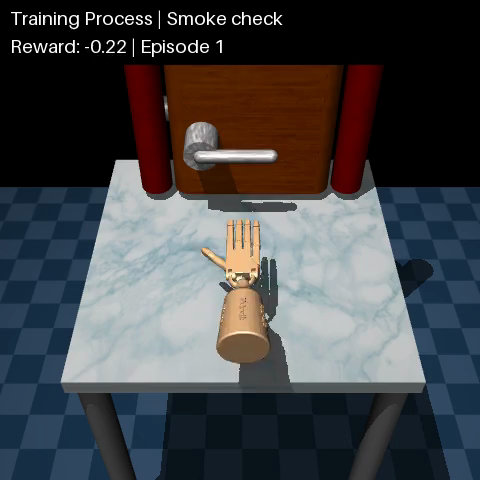

Smoke gates passed: training, checkpoint, reload, evaluation, MP4.


In [8]:
candidate_path, run_metadata = run_training(CONFIG["profile"])
if CONFIG["profile"] == "smoke":
    smoke_video = candidate_path.parent / "smoke_video.mp4"
    record_video(candidate_path, smoke_video, "Training Process | Smoke check", CONFIG["video_seed"])
    reader = imageio.get_reader(smoke_video)
    try:
        assert reader.count_frames() == CONFIG["expected_horizon"] * CONFIG["video_episodes"]
        display(Image.fromarray(reader.get_data(0)))
    finally:
        reader.close()
    print("Smoke gates passed: training, checkpoint, reload, evaluation, MP4.")


## Capítulo 4 — Métricas y gráficas

Pendiente de la tarea correspondiente del DWP.

## Capítulo 5 — Videos

Pendiente de la tarea correspondiente del DWP.